# Description

Prove that the Noise Reduction model works on a 2D polinomial.

Add libs folder path to system variables in order to make the importation of local libraries easier.

In [1]:
import os
import sys


CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(CURRENT_DIR)
print(CURRENT_DIR)

/home/jjavier98/S-noise-gradient


Import external and local libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from tqdm import tqdm
import math
from typing import List

# Locals
from src.libs.utils import *
from src.libs.dataset import TensorDataset
from src.libs.models import *
import src.libs.config as cfg
from src.libs.dlnr import DLNoiseReduction

Global / Path variables

In [3]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

Make sure that the GPU is being used

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

Functions definition

In [5]:
def polinomial_function(x:float):
    """
    Function that takes in a value x and returns its polinomial value.

    Args:
        x (float): value to be transformed.

    Returns:
        float: result of the polinomial function.
    """

    return x**4 -x**3 -20*(x**2) -20*x +6


def add_gaussian_noise(df:pd.DataFrame, columns:List[str], mean:float = 0.0, std:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df

Generate 2D data with normal distribution at the points indicated in ‘means’ variable.  
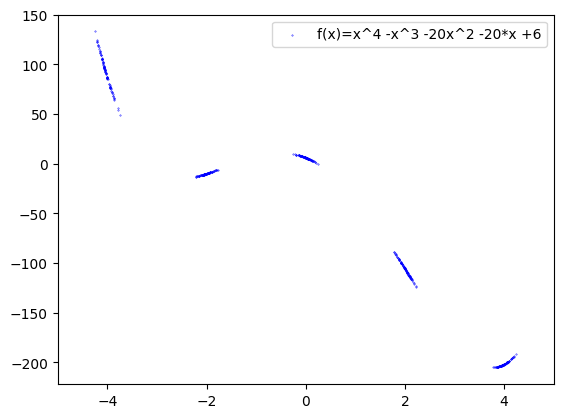

In [ ]:
# means = [-4, -2, 0, 2, 4]
# X_train = [np.random.normal(loc=m, scale=0.1, size=(100)) for m in means]
# X_train = np.concatenate(X_train, axis=0)
# y_train = polinomial_function(X_train)

# df_train = pd.DataFrame({'X': X_train, 'y': y_train})

Generate continious 2D data like so  
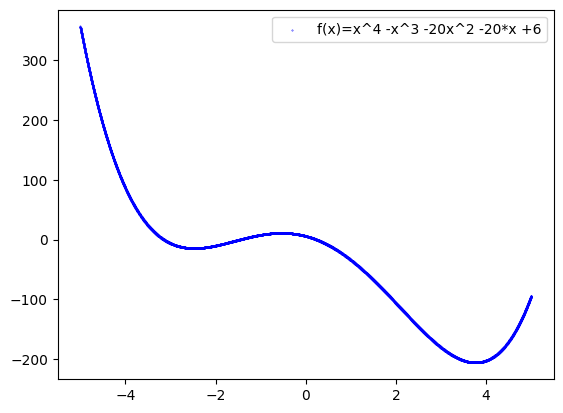

In [10]:
X = np.linspace(-5, 5, 5000)
y = polinomial_function(X)

df_data = pd.DataFrame({'X': X, 'y': y})
scaler = MinMaxScaler()
df_data = pd.DataFrame(scaler.fit_transform(df_data), columns=['X', 'y'])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df_data['X'].values, df_data['y'].values, test_size=0.2, random_state=42
)

# No noise XAI Benchmarck

In [ ]:
model_params = {
    'ridge': {"alpha": 1.0},
    'pls': {"n_components": 1},
    'tree': {"max_depth": 5},
    {"kernel": 'poly', "degree": 2},
    'knn': {"n_neighbors": 5, "weights": 'uniform', "algorithm": 'auto', "leaf_size": 30, "p": 2, "n_jobs": None},
}
xai_benchmark = XAI_benchmark(is_ts = False, model_params = model_params)

In [ ]:
xai_benchmark.fit(X_train.reshape(-1,1), y_train)

In [ ]:
xai_benchmark.predict(X_test.reshape(-1,1), y_test, get_metrics=True)

Add goussian noise to the dataframe

In [62]:
sigma = 0.035
df_noisy = add_gaussian_noise(
    df=df_data.copy(),
    columns=[x for x in df_data.columns],
    mean=0.0,
    std=sigma
)

Plot the new noisy data

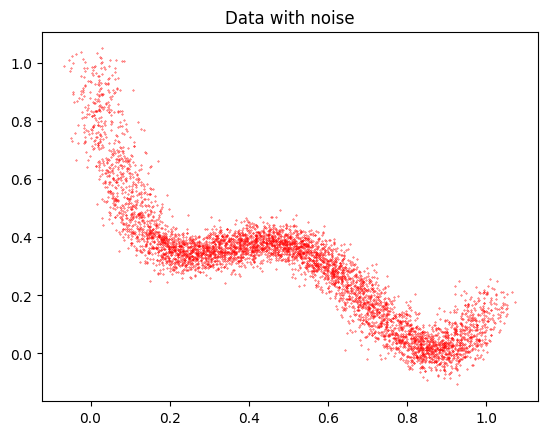

In [63]:
plt.title('Data with noise')
plt.scatter(df_noisy['X'], df_noisy['y'], color='r', s=0.1)

In [64]:
X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(
    df_noisy['X'].values, df_noisy['y'].values, test_size=0.2, random_state=42
)

# Noisy XAI Benchmarck

In [ ]:
xai_benchmark.fit(X_train_noisy.reshape(-1,1), y_train_noisy)

In [ ]:
xai_benchmark.predict(X_test_noisy.reshape(-1,1), y_test, get_metrics=True)

Create Datasets for DataLoaders

In [65]:
# Transform the data into a tensor
train_dataset = TensorDataset(
    x=X_train_noisy.reshape(-1,1),
    y=y_train_noisy.reshape(-1,1)
)
# Transform the data into a tensor
val_dataset = TensorDataset(
    x=X_test_noisy.reshape(-1,1),
    y=y_test_noisy.reshape(-1,1)
)

# Create the dataloaders
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

Create Neural Network model

In [66]:
model = GridFullyDenseNN(
    n_layers=4,
    hidden_layers=[
        (1, 1024),
        (1024, 512),
        (512, 1024),
        (1024, 1),
    ],
    dropout_layers=[
        0.0,
        0.0,
        0.0,
        0.0,
    ],
    activation_func_layers=[
        nn.Sigmoid(),
        nn.Sigmoid(),
        nn.Sigmoid(),
        nn.Sigmoid(),
    ],
    want_dropout=[
        False,
        False,
        False,
        False,
    ],
    want_linear=[
        True,
        True,
        True,
        True,
    ],
    want_activation=[
        True,
        True,
        True,
        True,
    ],
)
model.to(device)

GridFullyDenseNN(
  (model): Sequential(
    (linear_0): Linear(in_features=1, out_features=1024, bias=True)
    (activation_0): Sigmoid()
    (linear_1): Linear(in_features=1024, out_features=512, bias=True)
    (activation_1): Sigmoid()
    (linear_2): Linear(in_features=512, out_features=1024, bias=True)
    (activation_2): Sigmoid()
    (linear_3): Linear(in_features=1024, out_features=1, bias=True)
    (activation_3): Sigmoid()
  )
)

Set model parameters and create the model Trainer object

In [67]:
lr = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Define the trainer
trainer_basic = Trainer(
    model=model,
    train_generator=train_dataloader,
    val_generator=val_dataloader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience=15,
    epochs=500,
    checkpoints_path=os.path.join(CHECKPOINT_PATH, f'model_noise_{sigma}_polinomial')
)

Train the model

In [68]:
model, train_losses, val_losses, best_train_loss, best_val_loss = trainer_basic.fit(verbose=True)

Training is started!


Epochs loop:  11%|█         | 56/500 [00:29<03:51,  1.92epoch/s, Train loss: 0.0047]                   

Training stopped as validation loss did not improve for 15 epochs.


or load a checkpoint

In [69]:
# model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, f'model_noise_{sigma}_polinomial.pth')))

Predict over the datasets

In [70]:
y_pred_test = model(torch.tensor(X_test_noisy.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

Show the metrics

In [71]:
gt_values = y_test_noisy
predicted_values = y_pred_test

In [72]:
mae = mean_absolute_error(gt_values, predicted_values)
mse = mean_squared_error(gt_values, predicted_values)
rmse = np.sqrt(mse)
mape = np.mean(np.abs(gt_values - predicted_values) / gt_values) * 100
r_squared = r2_score(gt_values, predicted_values)
print("MAE: ", mae)
print("MAPE: ", mape)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R-squared: ", r_squared)

MAE:  0.04760441773416483
MAPE:  151.25219030530303
MSE:  0.004432421826238113
RMSE:  0.0665764359682772
R-squared:  0.8988370922497386


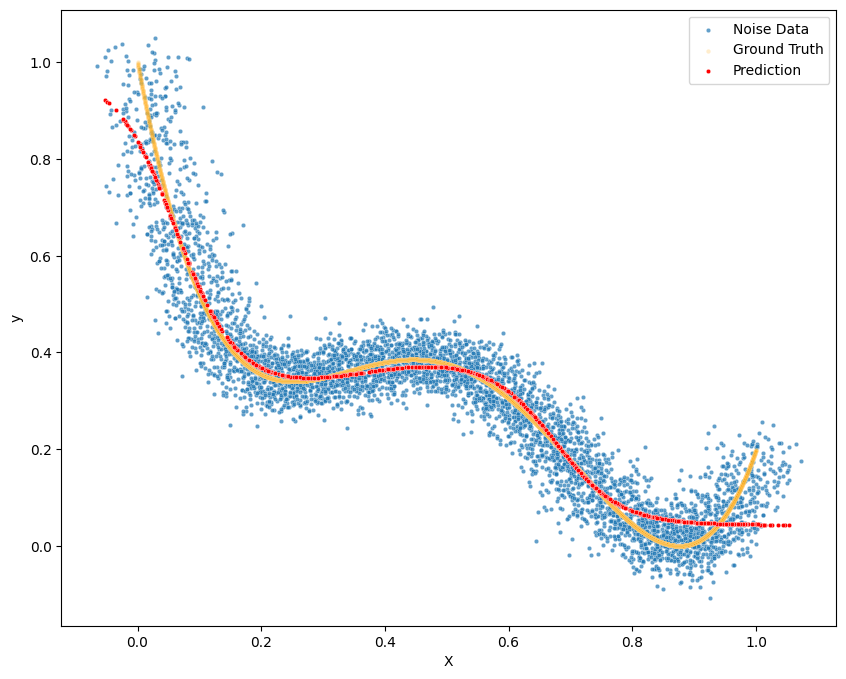

In [73]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.scatterplot(x=df_noisy['X'].values, y=df_noisy['y'].values, label='Noise Data', s=10, alpha=0.7)
sns.scatterplot(x=df_data['X'], y=df_data['y'], label='Ground Truth', s=10, alpha=0.2, color='orange')
sns.scatterplot(x=X_test_noisy, y=y_pred_test, label='Prediction', s=10, color='r')
plt.legend()
plt.show()

# Gradients to reduce noise

In [74]:
df_no_noise = df_noisy.copy()
dlnr = DLNoiseReduction(model=model, criterion=criterion)
dlnr.fit(df_noisy['X'].values.reshape(-1, 1), df_noisy['y'].values.reshape(-1, 1))

In [79]:
df_no_noise['X'], df_no_noise['y'], x_grad, y_grad = dlnr.transform(
    nrr=0.05,
    nr_threshold=0.02,
    max_epochs=200,
    plot_progress=False,
    path_to_save_imgs=None
)

Noise threshold reached in all data points.


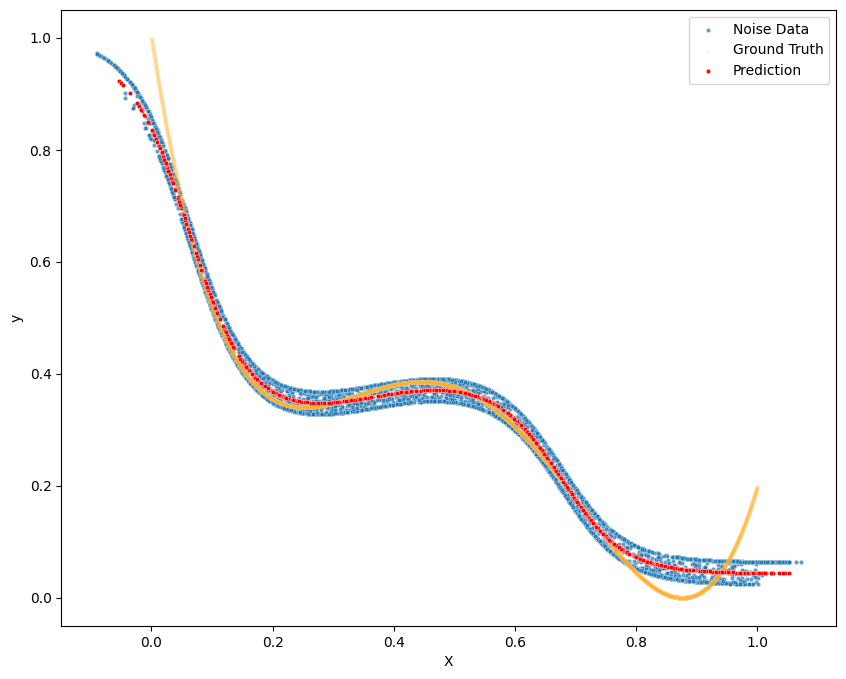

In [81]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.scatterplot(x=df_no_noise['X'].values, y=df_no_noise['y'].values, label='Noise Data', s=10, alpha=0.7)
sns.scatterplot(x=df_data['X'], y=df_data['y'], label='Ground Truth', s=10, alpha=0.1, color='orange')
sns.scatterplot(x=X_test_noisy, y=y_pred_test, label='Prediction', s=10, color='r')
plt.legend()
plt.show()

# Denoised XAI Benchmark

In [26]:
xai_benchmark.fit(df_no_noise['X'].values.reshape(-1,1), df_no_noise['y'].values)

NameError: name 'xai_benchmark' is not defined

In [ ]:
xai_benchmark.predict(df_no_noise['X'].values.reshape(-1,1), df_no_noise['y'].values.reshape(-1,1), get_metrics=True)

In [ ]:
xai_benchmark.predict(df_data['X'].values.reshape(-1,1), df_data['y'].values, get_metrics=True)

In [ ]:
xai_benchmark.predict(X_test_noisy.reshape(-1,1), y_test_noisy, get_metrics=True)